In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Load by file name
R2502_2504 = pd.read_pickle("R2502_2504.pkl")
R2504_2502 = pd.read_pickle("R2504_2502.pkl")
F2504 = pd.read_pickle("2504.pkl")

In [3]:
from pathlib import Path

# 1) Does a directory exist?
base = Path("/home/seismic/AxialFetch/MJ03F-E")
print(base, "→", base.exists(), "(dir)" if base.is_dir() else "(not a dir)")

# 2) Does one specific file exist?
f = base / "MJ03F-E2022DIFF-PRESS-15min.txt"
print(f, "→", f.exists())

# 3) Quick sweep over a pattern
for p in base.glob("MJ03F-E*DIFF-PRESS-15min.txt"):
    print("found:", p.name)


/home/seismic/AxialFetch/MJ03F-E → True (dir)
/home/seismic/AxialFetch/MJ03F-E/MJ03F-E2022DIFF-PRESS-15min.txt → True
found: MJ03F-E2023DIFF-PRESS-15min.txt
found: MJ03F-E2022DIFF-PRESS-15min.txt
found: MJ03F-E2021DIFF-PRESS-15min.txt
found: MJ03F-E2020DIFF-PRESS-15min.txt
found: MJ03F-E2019DIFF-PRESS-15min.txt
found: MJ03F-E2018DIFF-PRESS-15min.txt
found: MJ03F-E2017DIFF-PRESS-15min.txt
found: MJ03F-E2016DIFF-PRESS-15min.txt
found: MJ03F-E2015DIFF-PRESS-15min.txt
found: MJ03F-E2014DIFF-PRESS-15min.txt
found: MJ03F-E2024DIFF-PRESS-15min.txt


Rows in df_pressure: 1020


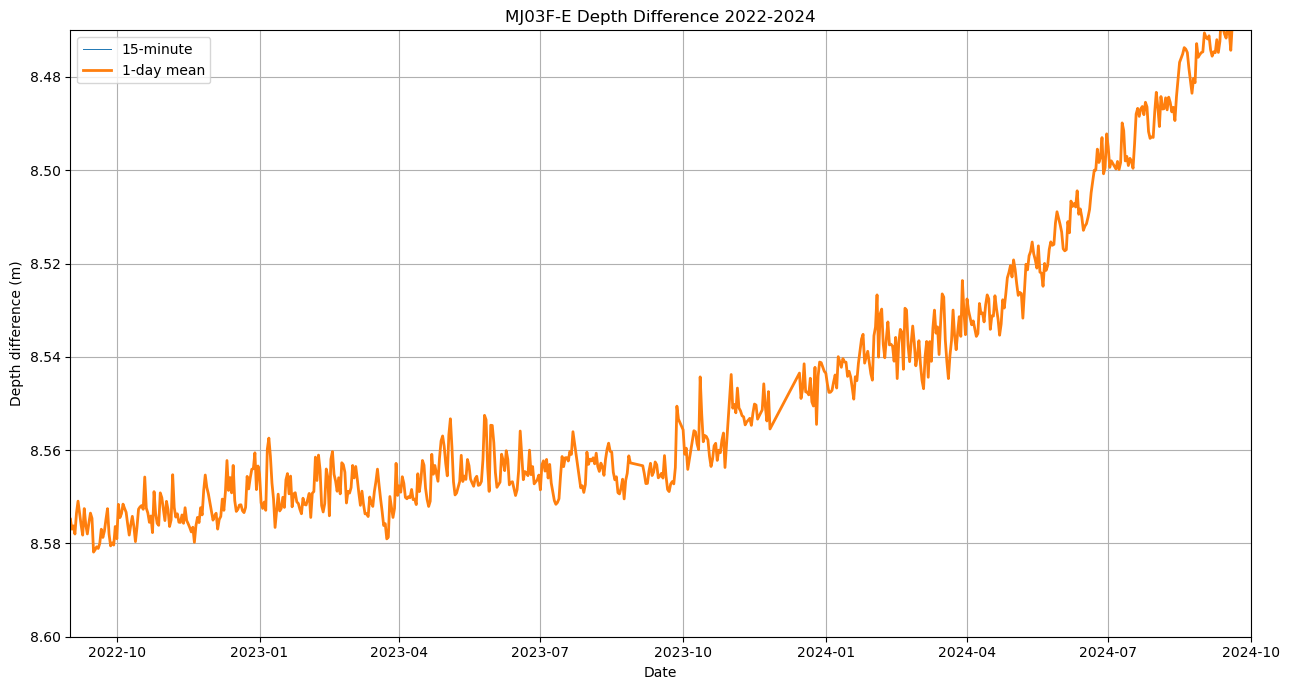

In [4]:
# MJ03F-B depth / pressure processing
# ----------------------------------
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

base_path = Path("/home/seismic/AxialFetch/MJ03F-E")
years     = range(2022, 2025)      # 2022-2024
factor    = 0.67                   # pressure-to-depth conversion

def load_series(years, suffix):
    """Read MJ03F-E DIFF-PRESS files (comma OR whitespace delimited)."""
    frames = []

    for yr in years:
        f = base_path / f"MJ03F-E{yr}DIFF-PRESS-{suffix}.txt"
        if not f.exists():
            continue

        # ---- peek at first line to decide the delimiter -----------------
        with open(f, "r") as fh:
            first_line = fh.readline()

        comma = "," in first_line
        read_opts = dict(
            comment="#",
            engine="python",          # tolerant, handles weird rows
            on_bad_lines="skip"       # silently drop malformed lines
        )

        if comma:
            df = pd.read_csv(f, **read_opts)
            # pick the known columns
            date_col      = df.columns[0]                       # e.g. 'date_1day'
            pressure_col  = (
                "pressure_diff_mean"
                if "pressure_diff_mean" in df.columns
                else df.columns[-1]                             # last numeric col
            )
            df = df[[date_col, pressure_col]]
            df.columns = ["time", "pressure_diff"]
        else:
            # whitespace version: two numeric cols after the date
            df = pd.read_csv(
                f,
                delim_whitespace=True,
                header=None,
                names=["time", "pressure_diff"],
                **read_opts,
            )

        # ---- type conversions & cleanup -------------------------------
        df["time"] = pd.to_datetime(df["time"], format="%Y/%m/%d",
                                    errors="coerce", utc=True)
        df["pressure_diff"] = pd.to_numeric(df["pressure_diff"],
                                            errors="coerce")
        df.dropna(subset=["time", "pressure_diff"], inplace=True)
        frames.append(df)

    if not frames:
        raise FileNotFoundError(f"No DIFF-PRESS-{suffix} data found.")
    return pd.concat(frames, ignore_index=True).sort_values("time")

# ----------------------------------------------------------------------
df_15min = load_series(years, "15min")
df_1day  = load_series(years, "1daymeans")

df_15min["depth_m"] = df_15min["pressure_diff"] * factor
df_1day ["depth_m"] = df_1day ["pressure_diff"] * factor

# minimalist (time, pressure) DF
df_pressure = df_1day[["time", "pressure_diff"]]

print("Rows in df_pressure:", len(df_pressure))   # sanity check

# ----------------------------------------------------------------------
# quick plot
plt.figure(figsize=(13, 7))
plt.plot(df_15min["time"], df_15min["depth_m"],
         label="15-minute", linewidth=0.7)
plt.plot(df_1day["time"],  df_1day["depth_m"],
         label="1-day mean", linewidth=2)
plt.gca().invert_yaxis()
plt.xlabel("Date")
plt.ylabel("Depth difference (m)")
plt.title("MJ03F-E Depth Difference 2022-2024")
plt.xlim(pd.Timestamp(2022, 9, 1, tz="UTC"),
         pd.Timestamp(2024, 10, 1, tz="UTC"))
plt.ylim(8.6, 8.47)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [5]:
import pandas as pd

# ------------------------------------------------------------------
# 1) helper → convert any table to a clean UTC-indexed Series
# ------------------------------------------------------------------
def to_series(df, time_col, value_col, fmt=None):
    s = (
        df[[time_col, value_col]]
        .assign(**{time_col: lambda d: pd.to_datetime(
            d[time_col], format=fmt, utc=True)})
        .set_index(time_col)[value_col]
        .astype(float)
        .sort_index()
        .loc[lambda x: ~x.index.duplicated(keep="first")]
    )
    return s

# ------------------------------------------------------------------
# 2) build the master grid from R2503_2504  (distance d1)
# ------------------------------------------------------------------
d1 = to_series(R2502_2504, "Record Time", "Moving Average")

df_var = d1.to_frame("d1")   # index = time, one column so far

# ------------------------------------------------------------------
# 3) prepare the other source series
# ------------------------------------------------------------------
# pressure difference p1 (comes from df_pressure)
p1 = (
    df_pressure.assign(time=pd.to_datetime(df_pressure["time"], utc=True))
               .set_index("time")["pressure_diff"]
               .astype(float)
               .sort_index()
               .loc[lambda x: ~x.index.duplicated(keep="first")]
)

# distance opposite direction d2
d2 = to_series(R2504_2502, "Record Time", "Moving Average")

# corrected pressure p2
p2 = to_series(F2504, "DateTime", "Corrected Pressure (kPa)")

In [6]:
# ------------------------------------------------------------------
# 4) interpolate everything onto the master grid
# ------------------------------------------------------------------
def onto_master(source, master_index):
    union = source.reindex(master_index.union(source.index))
    filled = union.interpolate("time")
    return filled.reindex(master_index)

df_var["p1"] = onto_master(p1, df_var.index)
df_var["d2"] = onto_master(d2, df_var.index)
df_var["p2"] = onto_master(p2, df_var.index)

# optional order
df_var = df_var[["p1", "p2", "d1", "d2"]]

# reset index so 'time' is a normal column
df_var = df_var.reset_index().rename(columns={"index": "time"})


In [7]:
df_var = df_var.dropna().reset_index(drop=True)

import pandas as pd

cutoff = pd.Timestamp(2022, 9, 7, tz="UTC")

# ensure 'time' is datetime and remove earlier rows
df_var["Record Time"] = pd.to_datetime(df_var["Record Time"], utc=True)
df_var = df_var[df_var["Record Time"] >= cutoff].reset_index(drop=True)


In [8]:
df_var['d1'] = df_var['d1']/100
df_var['d2'] = df_var['d2']/100
df_var

,Record Time,p1,p2,d1,d2
0,2022-09-07 03:30:00+00:00,12.796869,15562.229014,1642.111841,1642.100554
1,2022-09-07 07:30:00+00:00,12.797507,15562.125278,1642.109057,1642.097716
2,2022-09-07 19:30:00+00:00,12.799419,15562.088074,1642.107138,1642.097281
3,2022-09-07 23:30:00+00:00,12.800056,15562.048416,1642.105635,1642.095712
4,2022-09-08 03:30:00+00:00,12.800598,15562.090082,1642.103049,1642.093298
...,...,...,...,...,...
3814,2024-09-04 03:30:00+00:00,12.644200,15560.076672,1642.185344,1642.186758
3815,2024-09-04 07:30:00+00:00,12.644955,15560.297898,1642.185284,1642.186748
3816,2024-09-04 11:30:00+00:00,12.645709,15560.246149,1642.184816,1642.186299
3817,2024-09-04 15:30:00+00:00,12.646463,15560.180164,1642.184677,1642.186124


Text(0.5, 1.0, 'Central - East Distance')

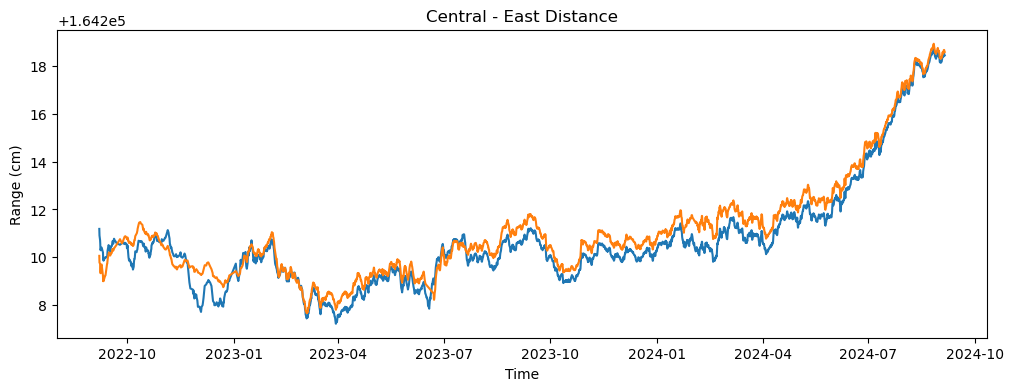

In [9]:
plt.figure(figsize=(12, 4))
plt.plot(df_var['Record Time'],df_var['d1']*100)
plt.plot(df_var['Record Time'],df_var['d2']*100)
plt.xlabel("Time")
plt.ylabel("Range (cm)")
plt.title("Central - East Distance")

In [17]:
import numpy as np

#-------------------------------------------------
# 1) EXTRACT ARRAYS
#-------------------------------------------------
time = df_var['Record Time'].values            # datetime64 array
p1   = df_var['p1'].values                     # differential pressure (ΔP)
r_CE = df_var['d1'].values                     # range E → C
r_EC = df_var['d2'].values                     # range C → E

#-------------------------------------------------
# 2) CONVERT TIME → FLOAT DAYS
#-------------------------------------------------
t_days = (time - time[0]) / np.timedelta64(1, 'D')   # float64, days since first record

#-------------------------------------------------
# 3) PERIODIC TERMS
#-------------------------------------------------
T_year = 365.25
ω      = 2.0 * np.pi / T_year
sin_t  = np.sin(ω * t_days)
cos_t  = np.cos(ω * t_days)

# -- 1. design matrix with intercept -------------------------------
p1_std = (p1 - p1.mean()) / p1.std()        # z-score   (keeps sign!)
A = np.column_stack([np.ones_like(p1),       # intercept
                     p1,                 # scaled ΔP
                     sin_t, cos_t])          # seasonal terms

# -- 2. solve -------------------------------------------------------
x_CE, *_ = np.linalg.lstsq(A, r_CE, rcond=None)
x_EC, *_ = np.linalg.lstsq(A, r_EC, rcond=None)

# -- 3. fitted curves ----------------------------------------------
r_CE_fit = A @ x_CE
r_EC_fit = A @ x_EC

#-------------------------------------------------
# 6) RESULTS
#-------------------------------------------------
print("==== Range C→E coefficients ====")
print(f"C_CE (intercept) : {x_CE[0]:.6f}")
print(f"a_CE (dP coeff)  : {x_CE[1]:.6f}")
print(f"b_CE (annual sin): {x_CE[2]:.6f}")
print(f"c_CE (annual cos): {x_CE[3]:.6f}")

print("\n==== Range E→C coefficients ====")
print(f"C_CE (intercept) : {x_CE[0]:.6f}")
print(f"a_EC (dP coeff)  : {x_EC[1]:.6f}")
print(f"b_EC (annual sin): {x_EC[2]:.6f}")
print(f"c_EC (annual cos): {x_EC[3]:.6f}")


==== Range C→E coefficients ====
C_CE (intercept) : 1648.502988
a_CE (dP coeff)  : -0.501321
b_CE (annual sin): 0.001640
c_CE (annual cos): 0.009280

==== Range E→C coefficients ====
C_CE (intercept) : 1648.502988
a_EC (dP coeff)  : -0.519142
b_EC (annual sin): 0.002541
c_EC (annual cos): 0.007988


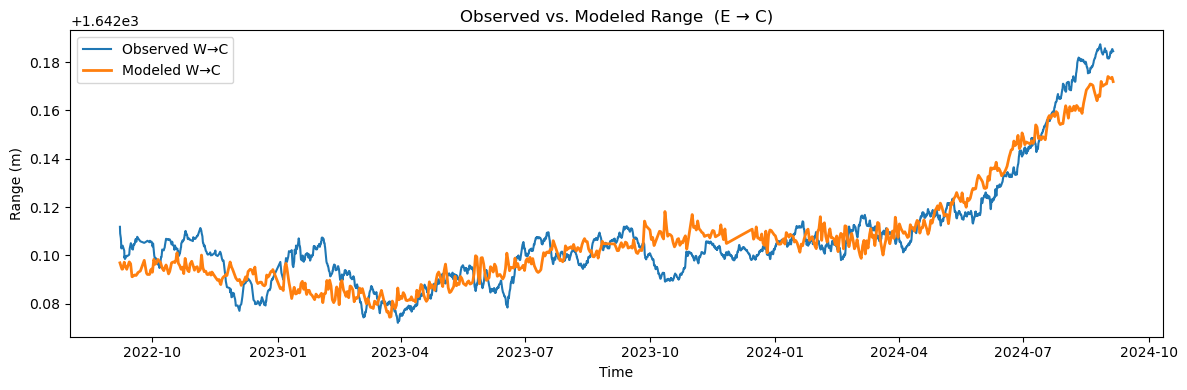

In [18]:
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# 6)  OBSERVED vs. MODELED  –  RANGE W→C  (r_CE)
# ------------------------------------------------------------------
plt.figure(figsize=(12, 4))
plt.plot(df_var['Record Time'], r_CE,      label='Observed W→C')
plt.plot(df_var['Record Time'], r_CE_fit,  label='Modeled W→C', linewidth=2)
plt.xlabel("Time")
plt.ylabel("Range (m)")
plt.title("Observed vs. Modeled Range  (E → C)")
plt.legend()
plt.tight_layout()
plt.show()

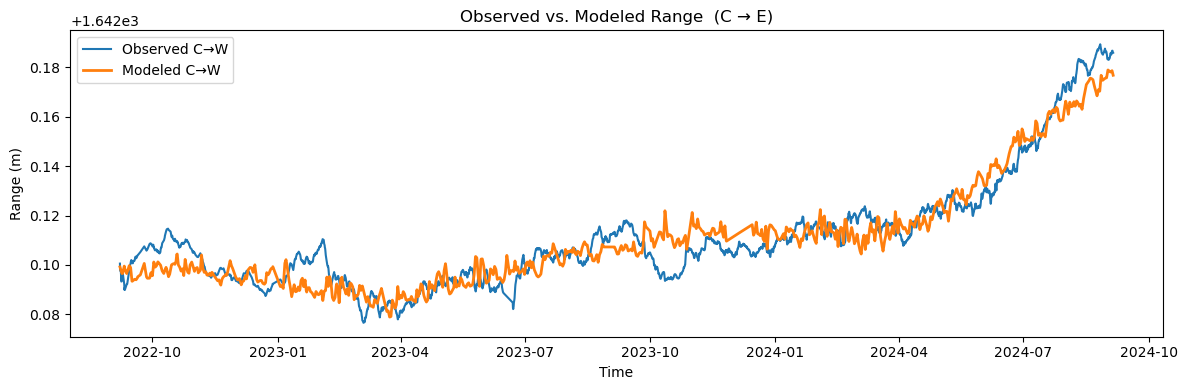

In [19]:
# ------------------------------------------------------------------
# 7)  OBSERVED vs. MODELED  –  RANGE C→W  (r_EC)
# ------------------------------------------------------------------
plt.figure(figsize=(12, 4))
plt.plot(df_var['Record Time'], r_EC,      label='Observed C→W')
plt.plot(df_var['Record Time'], r_EC_fit,  label='Modeled C→W', linewidth=2)
plt.xlabel("Time")
plt.ylabel("Range (m)")
plt.title("Observed vs. Modeled Range  (C → E)")
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
import numpy as np

#-------------------------------------------------
# 1) EXTRACT ARRAYS
#-------------------------------------------------
time = df_var['Record Time'].values
p2   = df_var['p2'].values          # absolute pressure  (P)
r_CE = df_var['d1'].values          # range E → C
r_EC = df_var['d2'].values          # range C → E

#-------------------------------------------------
# 2) TIME → FLOAT DAYS
#-------------------------------------------------
t_days = (time - time[0]) / np.timedelta64(1, 'D')

#-------------------------------------------------
# 3) PERIODIC TERMS
#-------------------------------------------------
T_year = 365.25
ω      = 2.0 * np.pi / T_year
sin_t  = np.sin(ω * t_days)
cos_t  = np.cos(ω * t_days)

#-------------------------------------------------
# 4) STANDARDISE PRESSURES  (z-score keeps sign but removes offset)
#-------------------------------------------------
p2_std = (p2 - p2.mean()) / p2.std()

#-------------------------------------------------
# 5) DESIGN MATRIX  (N × 5)  with intercept
#     R(t) = C + a·p1_std + b·p2_std + c·sin + d·cos
#-------------------------------------------------
A = np.column_stack([np.ones_like(p2), p2_std, sin_t, cos_t])

#-------------------------------------------------
# 6) LEAST-SQUARES FITS
#-------------------------------------------------
x_CE, *_ = np.linalg.lstsq(A, r_CE, rcond=None)   # (C_CE, a_CE, b_CE, c_CE, d_CE)
x_EC, *_ = np.linalg.lstsq(A, r_EC, rcond=None)   # (C_EC, a_EC, b_EC, c_EC, d_EC)

r_CE_fit = A @ x_CE
r_EC_fit = A @ x_EC

#-------------------------------------------------
# 7) RESULTS
#-------------------------------------------------
print("==== Range C→E coefficients ====")
print(f"C_CE (intercept) : {x_CE[0]:.6f}")
print(f"a_CE (Pc std)    : {x_CE[1]:.6f}")
print(f"c_CE (annual sin): {x_CE[2]:.6f}")
print(f"d_CE (annual cos): {x_CE[3]:.6f}")

print("\n==== Range E→C coefficients ====")
print(f"C_EC (intercept) : {x_EC[0]:.6f}")
print(f"a_EC (Pc std)    : {x_EC[1]:.6f}")
print(f"c_EC (annual sin): {x_EC[2]:.6f}")
print(f"d_EC (annual cos): {x_EC[3]:.6f}")


==== Range C→E coefficients ====
C_CE (intercept) : 1642.108456
a_CE (Pc std)    : -0.016143
c_CE (annual sin): -0.003394
d_CE (annual cos): 0.017194

==== Range E→C coefficients ====
C_EC (intercept) : 1642.112768
a_EC (Pc std)    : -0.016564
c_EC (annual sin): -0.002709
d_EC (annual cos): 0.016140


In [49]:
import numpy as np

#-------------------------------------------------
# 1) EXTRACT ARRAYS
#-------------------------------------------------
time = df_var['Record Time'].values
p1   = df_var['p1'].values          # differential pressure (ΔP)
p2   = df_var['p2'].values          # absolute pressure  (P)
r_CE = df_var['d1'].values          # range E → C
r_EC = df_var['d2'].values          # range C → E

#-------------------------------------------------
# 2) TIME → FLOAT DAYS
#-------------------------------------------------
t_days = (time - time[0]) / np.timedelta64(1, 'D')

#-------------------------------------------------
# 3) PERIODIC TERMS
#-------------------------------------------------
T_year = 365.25
ω      = 2.0 * np.pi / T_year
sin_t  = np.sin(ω * t_days)
cos_t  = np.cos(ω * t_days)

#-------------------------------------------------
# 4) STANDARDISE PRESSURES  (z-score keeps sign but removes offset)
#-------------------------------------------------
p1_std = (p1 - p1.mean()) / p1.std()
p2_std = (p2 - p2.mean()) / p2.std()

#-------------------------------------------------
# 5) DESIGN MATRIX  (N × 5)  with intercept
#     R(t) = C + a·p1_std + b·p2_std + c·sin + d·cos
#-------------------------------------------------
A = np.column_stack([np.ones_like(p1), p1_std, p2_std, sin_t, cos_t])

#-------------------------------------------------
# 6) LEAST-SQUARES FITS
#-------------------------------------------------
x_CE, *_ = np.linalg.lstsq(A, r_CE, rcond=None)   # (C_CE, a_CE, b_CE, c_CE, d_CE)
x_EC, *_ = np.linalg.lstsq(A, r_EC, rcond=None)   # (C_EC, a_EC, b_EC, c_EC, d_EC)

r_CE_fit = A @ x_CE
r_EC_fit = A @ x_EC

#-------------------------------------------------
# 7) RESULTS
#-------------------------------------------------
print("==== Range C→E coefficients ====")
print(f"C_CE (intercept) : {x_CE[0]:.6f}")
print(f"a_CE (ΔP std)    : {x_CE[1]:.6f}")
print(f"b_CE (P  std)    : {x_CE[2]:.6f}")
print(f"c_CE (annual sin): {x_CE[3]:.6f}")
print(f"d_CE (annual cos): {x_CE[4]:.6f}")

print("\n==== Range E→C coefficients ====")
print(f"C_EC (intercept) : {x_EC[0]:.6f}")
print(f"a_EC (ΔP std)    : {x_EC[1]:.6f}")
print(f"b_EC (P  std)    : {x_EC[2]:.6f}")
print(f"c_EC (annual sin): {x_EC[3]:.6f}")
print(f"d_EC (annual cos): {x_EC[4]:.6f}")


==== Range C→E coefficients ====
C_CE (intercept) : 1642.108771
a_CE (ΔP std)    : -0.018435
b_CE (P  std)    : -0.002473
c_CE (annual sin): 0.001400
d_CE (annual cos): 0.010292

==== Range E→C coefficients ====
C_EC (intercept) : 1642.113099
a_EC (ΔP std)    : -0.019369
b_EC (P  std)    : -0.002202
c_EC (annual sin): 0.002328
d_EC (annual cos): 0.008889


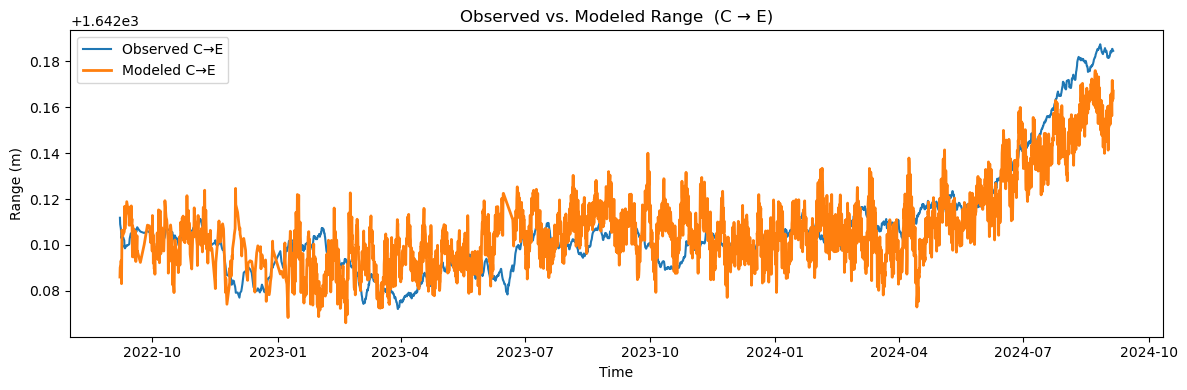

In [14]:
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# 6)  OBSERVED vs. MODELED  –  RANGE W→C  (r_CE)
# ------------------------------------------------------------------
plt.figure(figsize=(12, 4))
plt.plot(df_var['Record Time'], r_CE,      label='Observed C→E')
plt.plot(df_var['Record Time'], r_CE_fit,  label='Modeled C→E', linewidth=2)
plt.xlabel("Time")
plt.ylabel("Range (m)")
plt.title("Observed vs. Modeled Range  (C → E)")
plt.legend()
plt.tight_layout()
plt.show()

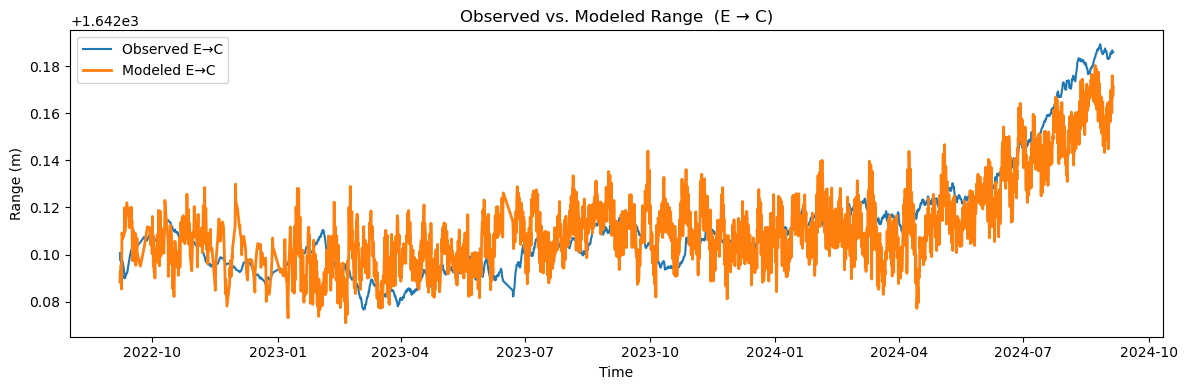

In [15]:
# ------------------------------------------------------------------
# 7)  OBSERVED vs. MODELED  –  RANGE C→W  (r_EC)
# ------------------------------------------------------------------
plt.figure(figsize=(12, 4))
plt.plot(df_var['Record Time'], r_EC,      label='Observed E→C')
plt.plot(df_var['Record Time'], r_EC_fit,  label='Modeled E→C', linewidth=2)
plt.xlabel("Time")
plt.ylabel("Range (m)")
plt.title("Observed vs. Modeled Range  (E → C)")
plt.legend()
plt.tight_layout()
plt.show()

In [52]:
from sklearn.metrics import r2_score
print('R² (E→C) =', r2_score(r_EC,  r_EC_fit))
print('R² (C→E) =', r2_score(r_CE,  r_CE_fit))


R² (E→C) = 0.8929243829833639
R² (C→E) = 0.869542565511559


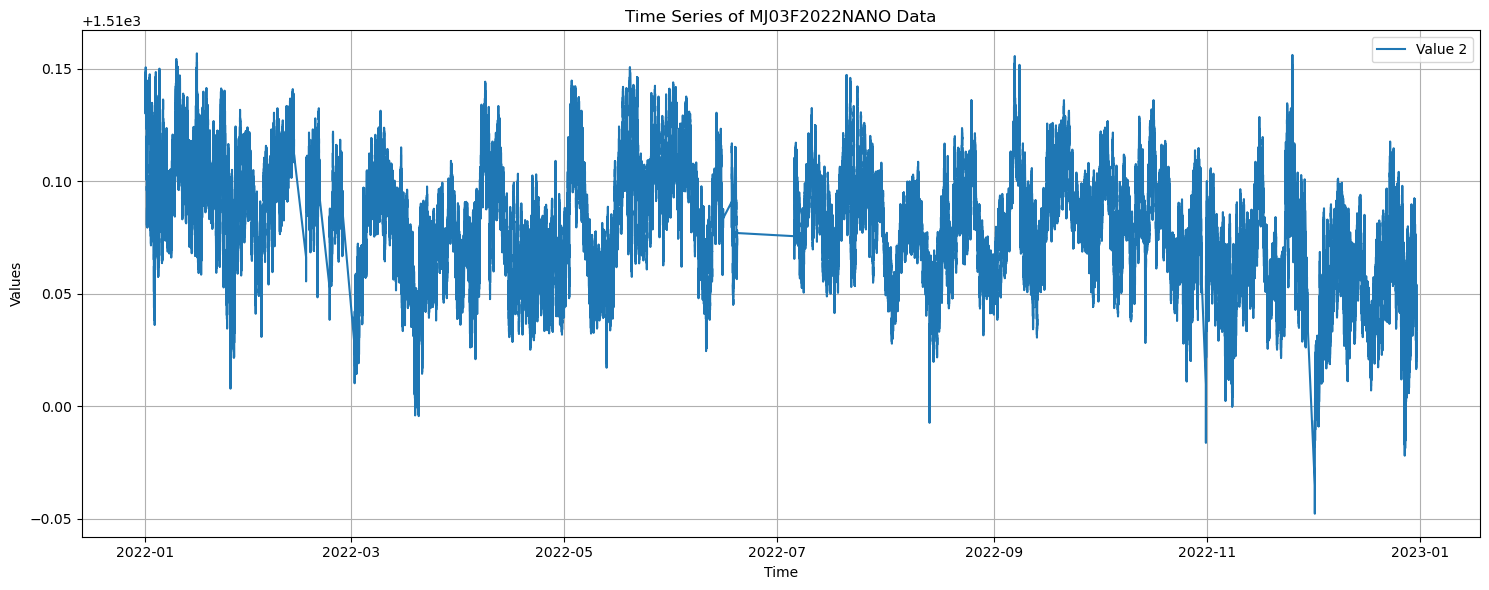

In [117]:
import matplotlib.pyplot as plt
file_path = "MJ03F2022NANO.Data"
# Load the data into a DataFrame
df = pd.read_csv(file_path, header=None, names=["time", "value1", "value2", "value3"])
df['time'] = pd.to_datetime(df['time'])

# Basic analysis: summary statistics
summary = df.describe()

# Plot the three values over time
plt.figure(figsize=(15, 6))
#plt.plot(df['time'], df['value1'], label='Value 1')
plt.plot(df['time'], df['value2'], label='Value 2')
#plt.plot(F2504['DateTime'], F2504['Corrected Pressure (kPa)'])
#plt.plot(df['time'], df['value3'], label='Value 3')
plt.xlabel('Time')
plt.ylabel('Values')
plt.title('Time Series of MJ03F2022NANO Data')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [118]:
df

,time,value1,value2,value3
0,2022-01-01 00:00:00,2251.6316,1510.1345,2.716402
1,2022-01-01 00:00:15,2251.6320,1510.1358,2.716386
2,2022-01-01 00:00:30,2251.6293,1510.1350,2.716387
3,2022-01-01 00:00:45,2251.6220,1510.1311,2.716394
4,2022-01-01 00:01:00,2251.6219,1510.1321,2.716377
...,...,...,...,...
1906027,2022-12-31 02:16:00,2254.3391,1510.0505,2.684240
1906028,2022-12-31 02:16:15,2254.3368,1510.0487,2.684221
1906029,2022-12-31 02:16:30,2254.3288,1510.0432,2.684214
1906030,2022-12-31 02:16:45,2254.3237,1510.0396,2.684203


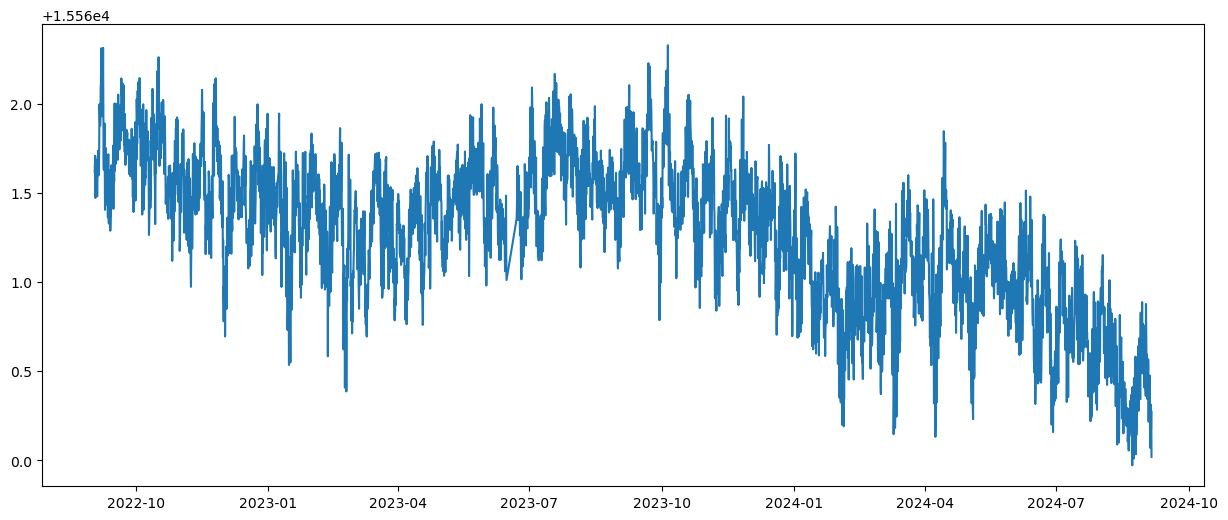

In [119]:
plt.figure(figsize=(15, 6))
plt.plot(F2504['DateTime'], F2504['Corrected Pressure (kPa)'])

In [120]:
F2504

,index,DateTime,Pressure (kPa),Temperature Deg C,TempDQZ,Salinity,Tidal Influence (kPa),Corrected Pressure (kPa),interp_v,velocity
Record Time,,,,,,,,,,
2022-09-02 11:45:00,0,2022-09-02 11:45:00,15566.25195,2.3874,2.46,34.529143,4.636196,15561.615754,1484.524225,1484.510759
2022-09-02 15:45:00,1,2022-09-02 15:45:00,15559.93652,2.3825,2.42,34.528767,-1.729555,15561.666075,1484.513100,1484.489025
2022-09-02 19:45:00,2,2022-09-02 19:45:00,15560.09082,2.3819,2.41,34.528866,-1.617206,15561.708026,1484.525100,1484.486612
2022-09-02 23:45:00,3,2022-09-02 23:45:00,15572.06641,2.3801,2.41,34.530268,10.594810,15561.471600,1484.537950,1484.480215
2022-09-03 03:45:00,4,2022-09-03 03:45:00,15561.18164,2.3734,2.40,34.530916,-0.327770,15561.509410,1484.488450,1484.451955
...,...,...,...,...,...,...,...,...,...,...
2024-09-04 07:45:00,4353,2024-09-04 07:45:00,15568.71875,2.4026,2.43,34.511523,8.405553,15560.313197,1484.552801,1484.551763
2024-09-04 11:45:00,4354,2024-09-04 11:45:00,15560.64160,2.3987,2.42,34.511523,0.399921,15560.241679,1484.521750,1484.534675
2024-09-04 15:45:00,4355,2024-09-04 15:45:00,15549.39160,2.3979,2.42,34.511523,-10.784463,15560.176063,1484.504979,1484.531085


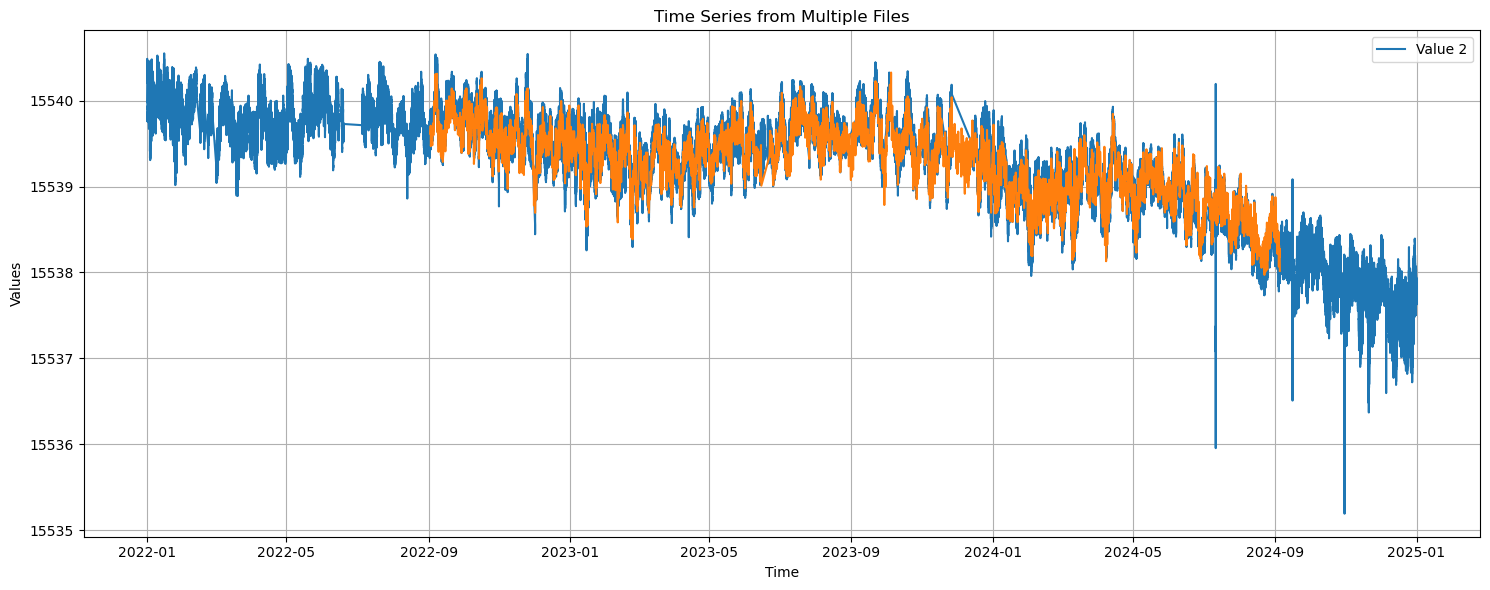

In [121]:
import pandas as pd
import matplotlib.pyplot as plt
import glob

# Specify the path and pattern to load multiple files
file_paths = glob.glob("*.Data")  # adjust path as needed

# Read and concatenate all files
df_list = []
for path in file_paths:
    temp_df = pd.read_csv(path, header=None, names=["time", "value1", "value2", "value3"])
    temp_df['time'] = pd.to_datetime(temp_df['time'])
    df_list.append(temp_df)

# Combine into one DataFrame
df = pd.concat(df_list, ignore_index=True).sort_values('time')


# Plotting
plt.figure(figsize=(15, 6))
#plt.plot(df['time'], df['value1'], label='Value 1')
plt.plot(df['time'], (df['value2']/0.67)*6.89476, label='Value 2')
plt.plot(F2504['DateTime'], F2504['Corrected Pressure (kPa)']-22)
#plt.plot(df['time'], df['value3'], label='Value 3')
plt.xlabel('Time')
plt.ylabel('Values')
plt.title('Time Series from Multiple Files')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [122]:
15540.320814-15561.270808860745

-20.949994860744482

In [123]:
a=F2504['Corrected Pressure (kPa)']-21.9
a

Record Time
2022-09-02 11:45:00    15539.715754
2022-09-02 15:45:00    15539.766075
2022-09-02 19:45:00    15539.808026
2022-09-02 23:45:00    15539.571600
2022-09-03 03:45:00    15539.609410
                           ...     
2024-09-04 07:45:00    15538.413197
2024-09-04 11:45:00    15538.341679
2024-09-04 15:45:00    15538.276063
2024-09-04 19:45:00    15538.375654
2024-09-04 23:45:00    15538.118424
Name: Corrected Pressure (kPa), Length: 4358, dtype: float64

In [128]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure datetime
df['time'] = pd.to_datetime(df['time'])

# Extract just the date part
df['date'] = df['time'].dt.date

# Define the target dates
target_dates = [pd.to_datetime('2022-09-02').date(), pd.to_datetime('2024-09-04').date()]

# Group by date and calculate mean for target dates
mean_vals = df[df['date'].isin(target_dates)].groupby('date')['value2'].mean()

# Scale the mean values
scaled_means = mean_vals

# Print scaled mean values
for date, val in scaled_means.items():
    print(f"{date}: {val:.4f}")


2022-09-02: 1510.0737
2024-09-04: 1509.9101


In [129]:
1510.0737-1509.9101

0.1635999999998603

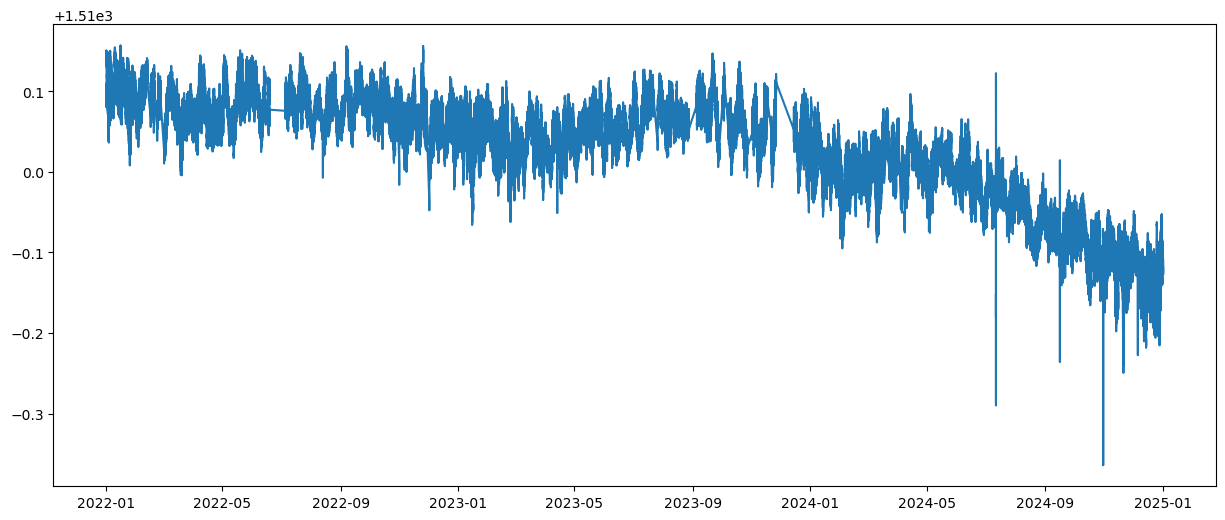

In [130]:
plt.figure(figsize=(15, 6))
plt.plot(df['time'], (df['value2']))